# Logging using the MLFlow Logger

This notebook demonstrates how to use the logging function for MLFLow

## Installation

You can install everything from the command line using the following commands.

### Installing Anomalib

The easiest way to install anomalib is to use pip.

In [ ]:
%pip install anomalib

### Install Anomalib and MLFlow

Install anomalib with MLFlow using pip.

In [ ]:
%pip install anomalib[loggers]

### Install MLFlow

Install MLFlow using pip.

In [ ]:
%pip install -qU mlflow

# Run MLFlow Server

You can execute the following command in a seperate terminal to access the MLFlow UI.

```bash
mlflow server --backend-store-uri ./examples/notebooks/05_loggers/mlruns/
```

Or you can return to the following cell, uncomment the cell and then execute it.

ATTENTION: This cell runs indefinitely and must be interrupted manually to continue!

In [ ]:
# !mlflow server

## Dataset Directory

This cell is to ensure we change the directory to have access to the datasets.

This part is borrowed from the datamodule mvtec notebook.

In [2]:
from pathlib import Path
print(f"Current working directory: {Path.cwd()}")
# NOTE: Provide the path to the dataset root directory.
#   If the datasets is not downloaded, it will be downloaded
#   to this directory.
dataset_root = Path.cwd().parent.parent / "datasets" / "MVTecAD"
print(f"Dataset root directory: {dataset_root}")

Current working directory: /home/admin_rech/repos/anomalib/examples/05_loggers
Dataset root directory: /home/admin_rech/repos/anomalib/datasets/MVTecAD


## Imports

In [7]:
import warnings

from lightning.pytorch.callbacks import EarlyStopping

from anomalib.callbacks.checkpoint import ModelCheckpoint
from anomalib.data import MVTecAD
from anomalib.engine import Engine
from anomalib.loggers import AnomalibMLFlowLogger, AnomalibWandbLogger
from anomalib.models import Fastflow

warnings.filterwarnings("ignore")

## Data Module

Using the data module to load the MVTec dataset. But first let's print the docstring.

In [4]:
help(MVTecAD)

Help on class MVTecAD in module anomalib.data.datamodules.image.mvtecad:

class MVTecAD(anomalib.data.datamodules.base.image.AnomalibDataModule)
 |  MVTecAD(
 |      root: Path | str = './datasets/MVTecAD',
 |      category: str = 'bottle',
 |      train_batch_size: int = 32,
 |      eval_batch_size: int = 32,
 |      num_workers: int = 8,
 |      train_augmentations: Transform | None = None,
 |      val_augmentations: Transform | None = None,
 |      test_augmentations: Transform | None = None,
 |      augmentations: Transform | None = None,
 |      test_split_mode: TestSplitMode | str = <TestSplitMode.FROM_DIR: 'from_dir'>,
 |      test_split_ratio: float = 0.2,
 |      val_split_mode: ValSplitMode | str = <ValSplitMode.SAME_AS_TEST: 'same_as_test'>,
 |      val_split_ratio: float = 0.5,
 |      seed: int | None = None
 |  ) -> None
 |
 |  MVTec AD Datamodule.
 |
 |  Args:
 |      root (Path | str): Path to the root of the dataset.
 |          Defaults to ``"./datasets/MVTecAD"``.
 |

In [12]:
datamodule = MVTecAD(
    root=dataset_root,
    category="bottle",
    train_batch_size=32,
    eval_batch_size=32,
    num_workers=24,
)

## Model

Setup Fastflow as an example model.

In [13]:
model = Fastflow(backbone="resnet18", flow_steps=8)

## MLFlow Logger

Setup the MLFlow logger. But first let's print the docstring.

In [8]:
help(AnomalibWandbLogger)

Help on class AnomalibWandbLogger in module anomalib.loggers.wandb:

class AnomalibWandbLogger(anomalib.loggers.base.ImageLoggerBase, lightning.pytorch.loggers.wandb.WandbLogger)
 |  AnomalibWandbLogger(
 |      name: str | None = None,
 |      save_dir: _PATH = '.',
 |      version: str | None = None,
 |      offline: bool = False,
 |      dir: _PATH | None = None,
 |      id: str | None = None,
 |      anonymous: bool | None = None,
 |      project: str | None = None,
 |      log_model: Literal['all'] | bool = False,
 |      experiment: Run | RunDisabled | None = None,
 |      prefix: str = '',
 |      checkpoint_name: str | None = None,
 |      **kwargs
 |  ) -> None
 |
 |  Logger for Weights & Biases with image logging capabilities.
 |
 |  This logger extends PyTorch Lightning's WandbLogger with an interface for
 |  logging images. It inherits from both :class:`ImageLoggerBase` and
 |  :class:`WandbLogger`.
 |
 |  Args:
 |      name: Display name for the run. Defaults to ``None``.


In [5]:
help(AnomalibMLFlowLogger)

Help on class AnomalibMLFlowLogger in module anomalib.loggers.mlflow:

class AnomalibMLFlowLogger(anomalib.loggers.base.ImageLoggerBase, lightning.pytorch.loggers.mlflow.MLFlowLogger)
 |  AnomalibMLFlowLogger(
 |      experiment_name: str | None = 'anomalib_logs',
 |      run_name: str | None = None,
 |      tracking_uri: str | None = None,
 |      save_dir: str | None = './mlruns',
 |      log_model: Literal['all'] | bool | None = False,
 |      prefix: str | None = '',
 |      **kwargs
 |  ) -> None
 |
 |  Logger for MLFlow with image logging capabilities.
 |
 |  This logger extends PyTorch Lightning's MLFlowLogger with an interface for
 |  logging images. It inherits from both :class:`ImageLoggerBase` and
 |  :class:`MLFlowLogger`.
 |
 |  Args:
 |      experiment_name: Name of the experiment. If not provided, defaults to
 |          ``"anomalib_logs"``.
 |      run_name: Name of the new run. The ``run_name`` is internally stored as
 |          a ``mlflow.runName`` tag. If the ``mlfl

In [14]:
mlflow_logger = AnomalibMLFlowLogger()

## Training

### Callbacks

In [22]:
model_checkpoint = ModelCheckpoint(mode="max", monitor="pixel_AUROC")

early_stopping = EarlyStopping(monitor="pixel_AUROC", mode="max", patience=3)

### Setup Engine

In [23]:
callbacks = [
    model_checkpoint,
    early_stopping,
]

kwargs = {"log_every_n_steps": 3}

engine = Engine(
    callbacks=callbacks,
    accelerator="auto",
    devices=1,
    logger=mlflow_logger,  # Logger is set here
    **kwargs,
)

### Fit the Model

In [24]:
engine.fit(model=model, datamodule=datamodule)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True


INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name           ┃ Type          ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ pre_processor  │ PreProcessor  │      0 │ train │     0 │
│ 1 │ post_processor │ PostProcessor │      0 │ train │     0 │
│ 2 │ evaluator      │ Evaluator     │      0 │ train │     0 │
│ 3 │ model          │ FastflowModel │  7.7 M │ train │     0 │
│ 4 │ loss           │ FastflowLoss  │      0 │ train │     0 │
└───┴────────────────┴───────────────┴────────┴───────┴───────┘

Trainable params: 3.5 M                                                                                            
Non-trainable params: 4.2 M                                                                                        
Total params: 7.7 M                                                                                                
Total estimated model params size (MB): 30                                                                         
Modules in train mode: 199                                                                                         
Modules in eval mode: 68                                                                                           
Total FLOPs: 0

Output()

INFO:pytorch_lightning.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


SystemExit: 1

## Testing

In [18]:
engine.test(model=model, dataloaders=datamodule.test_dataloader())

The following callbacks returned in `LightningModule.configure_callbacks` will override existing callbacks passed to Trainer: Evaluator, ImageVisualizer, PostProcessor, PreProcessor
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│        image_AUROC        │    0.9992064237594604     │
│       image_F1Score       │    0.9841269850730896     │
│        pixel_AUROC        │    0.9744592308998108     │
│       pixel_F1Score       │     0.671394944190979     │
└───────────────────────────┴───────────────────────────┘

[{'image_AUROC': 0.9992064237594604,
  'image_F1Score': 0.9841269850730896,
  'pixel_AUROC': 0.9744592308998108,
  'pixel_F1Score': 0.671394944190979}]

## Demo Track Figure

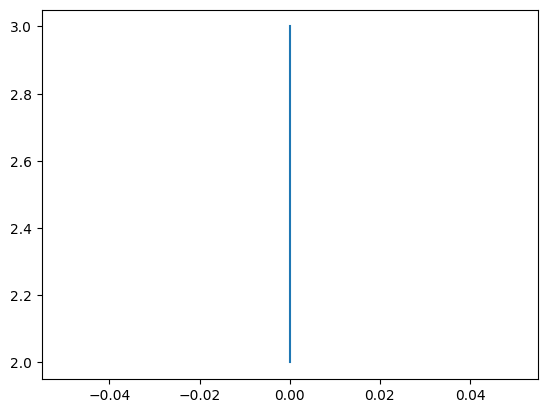

In [19]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots()
ax.plot([0, 0], [2, 3])

mlflow_logger.add_image(fig, "figure_demo.png")

## Save Model to MLFlow

In [20]:
import mlflow

with mlflow.start_run(run_id=mlflow_logger.run_id):
    mlflow.pytorch.log_model(engine.model.model, "Fastflow")

COMET INFO: Resumed MLFlow run are tracked as new Comet.ml Experiments
COMET INFO: No Comet API Key was found, creating an offline experiment. Set up your API Key to get the full Comet experience https://www.comet.com/docs/python-sdk/advanced/#python-configuration
COMET WARNING: To get all data logged automatically, import comet_ml before the following modules: sklearn, torch.
COMET WARNING: As you are running in a Jupyter environment, you will need to call `experiment.end()` when finished to ensure all metrics and code are logged before exiting.
COMET INFO: Using '/home/admin_rech/repos/anomalib/examples/05_loggers/.cometml-runs' path as offline directory. Pass 'offline_directory' parameter into constructor or set the 'COMET_OFFLINE_DIRECTORY' environment variable to manually choose where to store offline experiment archives.
COMET INFO: Couldn't find a Git repository in '/home/admin_rech/repos/anomalib/examples/05_loggers' nor in any parent directory. Set `COMET_GIT_DIRECTORY` if you

## Load Model from MLFlow

In [21]:
model_uri = f"runs:/{mlflow_logger.run_id}/Fastflow"
mlflow.pytorch.load_model(model_uri)

FastflowModel(
  (feature_extractor): FeatureListNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (drop_block): Identity()
        (act1): ReLU(inplace=True)
        (aa): Identity()
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act2): ReLU(inplace=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stri